# Model training

Trains and — more importantly — honestly evaluates a per-pixel classifier for waterhole
surface state.

## Read this before reading any score

**Your effective sample size is the number of labelled sites, not pixels.** The table below
has ~32,000 rows, but pixels within a tile are almost perfectly autocorrelated: knowing one
tells you most of what its neighbours will say. With 9 labelled sites, the honest n is 9.

Every split in this notebook therefore holds out **whole waterholes**. `wh_train` has no
code path for a random pixel-level split — it does not import `train_test_split` or `KFold`
at all, and its only splitter raises if handed fewer than 3 sites. A random split here would
report something like 0.95 and mean nothing.

Expect the flexible models to do *worse* than the simple one. That is not a bug; it is what
overfitting to 9 sites looks like.

In [28]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "cookie-cutting" else Path.cwd() / "cookie-cutting"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import wh_config
import wh_features
import wh_inventory
import wh_plots
import wh_tiles
import wh_train

pd.set_option("display.width", 140)

cfg = wh_config.load()
manifest = wh_inventory.load_manifest(cfg)
print("config", cfg.source_path.name, "hash", cfg.hash)

config waterhole_seg_config.yaml hash afde19a3ff27


## Parameters

In [29]:
PARAMS = wh_features.FeatureParams(
    # 60 m atmospheric bands B1 and B9 excluded: resampled to 10 m they carry no
    # surface information worth having.
    reflectance_bands=("B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"),

    indices=("mndwi", "ndwi", "ndvi", "ndti", "ndmi", "nd_rededge",
             "red_green_ratio", "awei_sh", "awei_nsh"),

    # Windowed mean and SD, so a pixel knows whether it sits in a uniform patch
    # or on an edge. NaN-aware: a window overlapping a cloud gap averages the
    # pixels that were observed, not zeros. These turn out to be the strongest
    # features in the whole stack — mndwi_sd9 ranks first on permutation
    # importance, ahead of every raw index.
    context_windows=(3, 9),
    context_indices=("mndwi", "ndvi"),

    # Indices given the full temporal treatment. NDTI carries turbidity and NDMI
    # responds to water UNDER a canopy — the case MNDWI gets wrong when sedges
    # cover a waterhole.
    temporal_indices=("mndwi", "ndvi", "ndti", "ndmi"),

    # n_obs is NOT a training feature. It describes the observing system, not the
    # ground: wet months have both fewer clear scenes and more water, so a model
    # can learn "few observations therefore wet" instead of reading the surface.
    # It ranked 2nd of 121 features on permutation importance, which is what that
    # shortcut looks like. Dropping it costs 0.006 macro F1 and buys a model that
    # will not degrade in a year with different cloud cover.
    include_n_obs=False,

    # AlphaEarth annual embeddings: 64 static learned dimensions per pixel,
    # downloaded onto exactly the Sentinel-2 grid. See the ablation below for
    # what they are worth here (spoiler: +0.004 macro F1).
    use_alphaearth=True,
    alphaearth_year=2025,
    # alphaearth_bands=None,      # None = all 64, or a tuple like ("A63", "A22")
    alphaearth_bands=("A28", "A32", "A63")
)

# --- training run ---------------------------------------------------------
# Every split is grouped by site whichever strategy is chosen; wh_train has no
# code path for a random pixel-level split.
TRAIN = wh_train.TrainParams(
    # "group_kfold_by_site" — n_splits folds however many sites there are. Fast,
    #     and near-constant cost as labelling grows. Folds are balanced by PIXEL
    #     count, so one can hold a single large site and another several small
    #     ones, which makes per-fold scores less comparable.
    # "leave_one_site_out" — one fold per site. Most informative, and the only
    #     setting under which the per-site table has one row per waterhole. Costs
    #     one model fit per site: at 25 sites that is 25 fits per model, times
    #     three models, times every feature set in the ablation.
    #
    # Work with k-fold; switch to LOSO for the run whose numbers you will quote.
    cv_strategy="group_kfold_by_site",
    n_splits=5,

    # Guards the DEFAULT only. If cv_strategy is leave_one_site_out and there are
    # more sites than this, it falls back to k-fold and says so. Passing
    # strategy= to cross_validate always wins.
    max_sites_for_loso=15,

    # Reported alongside, and optimistically biased: a held-out month's temporal
    # features were computed from that pixel's whole history, training months
    # included. The grouped-site CV has no equivalent leak.
    temporal_holdout_months=(8, 9, 10),

    # Surrounding vegetation and dry bare ground vastly outnumber the rest.
    class_weight="balanced",

    models=("logistic_regression", "random_forest", "gradient_boosting"),
    random_state=42,
)

INCLUDE_PSEUDO = False    # run pseudo_labelling.ipynb first, then try True
REBUILD_TABLE = True      # False reloads the cached table from derived/

TRAIN

TrainParams(cv_strategy='group_kfold_by_site', n_splits=5, max_sites_for_loso=15, temporal_holdout_months=(8, 9, 10), class_weight='balanced', models=('logistic_regression', 'random_forest', 'gradient_boosting'), include_pseudo_labels=False, random_state=42)

## Build the training table

One row per labelled pixel, carrying `site_id` and `year_month` alongside every feature.
Those two columns are what make a grouped split possible, so they travel with every row.

Sites are processed one at a time so each site's temporal features are computed once rather
than once per labelled month. Expect a couple of minutes.

In [30]:
if REBUILD_TABLE:
    table = wh_train.build_training_table(manifest, cfg, PARAMS, include_pseudo=INCLUDE_PSEUDO)
    wh_train.save_table(table, cfg)
else:
    table = wh_train.load_table(cfg)

features = wh_features.feature_columns(table)
print(f"\n{len(table):,} rows x {len(features)} features")
print(f"{table['site_id'].nunique()} sites, {table['year_month'].nunique()} months")
print(f"sources: {table['source'].value_counts().to_dict()}")

  site 000: 6 mask(s), 78 rows so far
  site 001: 3 mask(s), 95 rows so far
  site 002: 24 mask(s), 11,160 rows so far
  site 003: 5 mask(s), 12,545 rows so far
  site 004: 5 mask(s), 13,649 rows so far
  site 005: 10 mask(s), 17,230 rows so far
  site 006: 9 mask(s), 17,713 rows so far
  site 007: 4 mask(s), 19,126 rows so far
  site 009: 3 mask(s), 20,287 rows so far
  site 013: 27 mask(s), 28,012 rows so far
  site 016: 20 mask(s), 34,230 rows so far
  site 019: 13 mask(s), 35,122 rows so far
  site 022: 11 mask(s), 37,372 rows so far
  site 025: 15 mask(s), 46,998 rows so far
  site 028: 16 mask(s), 49,861 rows so far
  site 034: 7 mask(s), 50,767 rows so far
  site 040: 25 mask(s), 51,201 rows so far
  site 046: 8 mask(s), 51,772 rows so far
  site 048: 17 mask(s), 65,183 rows so far
  site 049: 1 mask(s), 66,472 rows so far
  site 050: 19 mask(s), 70,701 rows so far
  site 064: 2 mask(s), 71,376 rows so far
  site 065: 2 mask(s), 75,245 rows so far
  site 066: 1 mask(s), 76,406 r

### Class coverage — the table that predicts what will fail

Read the **sites** column, not the pixels column. A class present at only 2 sites will be
absent from training entirely in some folds, and cannot be expected to work.

In [31]:
coverage = table.groupby("class_id").agg(
    pixels=("row", "size"),
    tiles=("year_month", "nunique"),
    sites=("site_id", "nunique"),
)
coverage.insert(0, "class", [cfg.class_by_id(i).name for i in coverage.index])
coverage = coverage.sort_values("sites")

thin = coverage[coverage["sites"] < 3]
if len(thin):
    print("classes at fewer than 3 sites — expect these to fail, and not because "
          "the model is bad:")
    print("  " + ", ".join(thin["class"]))
coverage

,class,pixels,tiles,sites
class_id,,,,
1,open_water,2900,5,5
2,turbid_water,5855,32,8
6,surrounding_vegetation,41013,20,9
4,mud,4457,52,19
3,aquatic_vegetation,12588,27,20
5,dry_bare,28557,36,20


In [32]:
# Features that are mostly NaN mean too few pixels had enough observed months
# to fit — a data problem, not something for the imputer to paper over.
missing = wh_features.describe_missing(table, threshold=0.2)
print(f"{len(missing)} feature(s) more than 20% NaN")
missing.head(10)

1 feature(s) more than 20% NaN


,nan_fraction
months_since_water,0.828437


### Feature blocks

What the ablation below can switch on and off. `alphaearth` is empty unless
`use_alphaearth=True` in the params above.

In [33]:
blocks = wh_train.feature_blocks(table, PARAMS)
for name, columns in blocks.items():
    print(f"  {name:22s} {len(columns):>4d}")
print(f"  {'TOTAL':22s} {sum(len(c) for c in blocks.values()):>4d}")

  instantaneous            27
  temporal_model_free      29
  temporal_trend            0
  temporal_harmonic         0
  alphaearth                3
  TOTAL                    59


## Cross-validation

Every fold holds out whole waterholes — `wh_train` has no code path for a random pixel-level
split, and its only splitter raises if handed fewer than 3 sites.

`CV_STRATEGY` in the params cell controls the cost. With 25 labelled sites, leave-one-site-out
is 25 model fits per model and considerably more again for the ablation, so k-fold is the
sensible default while iterating. Switch to `"leave_one_site_out"` for a final run: it is more
informative, and it is the only setting under which the per-site table has one row per
waterhole.

The fold count is printed before each run, so which one is in force is never a guess.

In [34]:
results = {}
for model_name in TRAIN.models:
    print(f"\n=== {model_name} ===")
    results[model_name] = wh_train.cross_validate(
        table, cfg, model_name, train_params=TRAIN
    )
    print(results[model_name].summary())

print("\n" + "=" * 60)
pd.DataFrame([
    {"model": name, "macro_f1": ev.macro_f1, "weighted_f1": ev.weighted_f1}
    for name, ev in results.items()
]).set_index("model").round(3)


=== logistic_regression ===
  logistic_regression: 5 fold(s) over 27 sites, 59 features
  held out fold0:005+019+048+066: macro F1 0.739 (19,045 px, 6 classes)
  held out fold1:000+002+004+022+046+065: macro F1 0.780 (18,937 px, 6 classes)
  held out fold2:001+025+028+034+049+050: macro F1 0.683 (18,930 px, 6 classes)
  held out fold3:007+009+016+040+064+096: macro F1 0.611 (19,271 px, 5 classes)
  held out fold4:003+006+013+070+094: macro F1 0.716 (19,187 px, 6 classes)
logistic_regression    macro F1 0.779  weighted F1 0.853  (95,370 test rows)

=== random_forest ===
  random_forest: 5 fold(s) over 27 sites, 59 features
  held out fold0:005+019+048+066: macro F1 0.845 (19,045 px, 6 classes)
  held out fold1:000+002+004+022+046+065: macro F1 0.821 (18,937 px, 6 classes)
  held out fold2:001+025+028+034+049+050: macro F1 0.652 (18,930 px, 6 classes)
  held out fold3:007+009+016+040+064+096: macro F1 0.671 (19,271 px, 5 classes)
  held out fold4:003+006+013+070+094: macro F1 0.679 (19,

,macro_f1,weighted_f1
model,,
logistic_regression,0.779,0.853
random_forest,0.825,0.887
gradient_boosting,0.856,0.894


**Logistic regression is a diagnostic, not a contender.**

If a linear model on the same features generalises better
to a held-out waterhole, that is the signal to add *labelled sites*, not more features or a
bigger model.

The best model is therefore chosen from the scores below rather than fixed in advance — the
ranking will shift as you label more, and it should.

In [35]:
# Chosen on cross-validated evidence, not decided in advance.
BEST = max(results, key=lambda name: results[name].macro_f1)

print("leave-one-site-out macro F1:")
for name, ev in sorted(results.items(), key=lambda kv: -kv[1].macro_f1):
    marker = "  <- selected" if name == BEST else ""
    print(f"  {name:22s} {ev.macro_f1:.3f}{marker}")

# BEST = "gradient_boosting"    # uncomment to override the choice
evaluation = results[BEST]

print(f"\nper class ({BEST}):")
print(evaluation.per_class.round(3).to_string())
print("\nmacro F1 weights every class equally, so the rare broken ones drag it down;")
print("weighted F1 is dominated by surrounding vegetation and dry bare ground.")

leave-one-site-out macro F1:
  gradient_boosting      0.856  <- selected
  random_forest          0.825
  logistic_regression    0.779

per class (gradient_boosting):
                        precision  recall     f1    iou  support
class                                                           
open_water                  0.947   0.834  0.887  0.797     2900
turbid_water                0.894   0.934  0.914  0.841     5855
aquatic_vegetation          0.949   0.938  0.943  0.893    12588
mud                         0.659   0.549  0.599  0.427     4457
dry_bare                    0.850   0.874  0.862  0.757    28557
surrounding_vegetation      0.929   0.932  0.931  0.870    41013

macro F1 weights every class equally, so the rare broken ones drag it down;
weighted F1 is dominated by surrounding vegetation and dry bare ground.


In [36]:
print("per site — the table that matters:")
print()
print("Sites with very few labelled classes are not comparable with the rest:")
print("macro F1 averages over the classes PRESENT, so a site with one labelled")
print("class can score badly on a technicality. Read n_classes alongside the score.")
evaluation.per_site.round(3)

per site — the table that matters:

Sites with very few labelled classes are not comparable with the rest:
macro F1 averages over the classes PRESENT, so a site with one labelled
class can score badly on a technicality. Read n_classes alongside the score.


,n_pixels,n_classes,macro_f1,accuracy
site_id,,,,
000,78,1,0.017,0.026
065,3869,1,0.278,0.384
064,675,2,0.287,0.776
040,434,3,0.382,0.783
028,2863,5,0.395,0.851
034,906,2,0.397,0.987
004,1104,2,0.496,0.620
066,1161,1,0.499,0.996
009,1161,3,0.500,0.939


### Diagnostic plots

The confusion matrix normalised by true class — "of the pixels that really were mud, where
did they go?" — with raw counts in each cell so the support behind each rate stays visible.
A 100% rate over 12 pixels is not the same claim as 100% over 12,000.

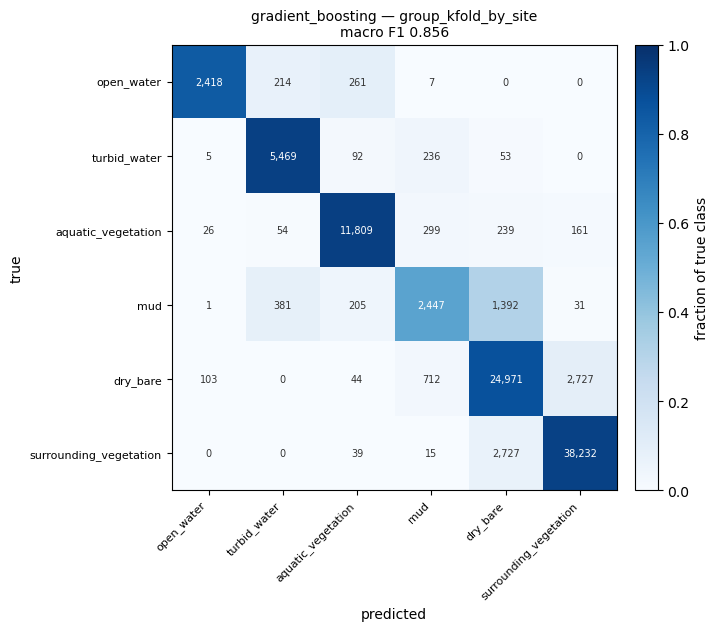

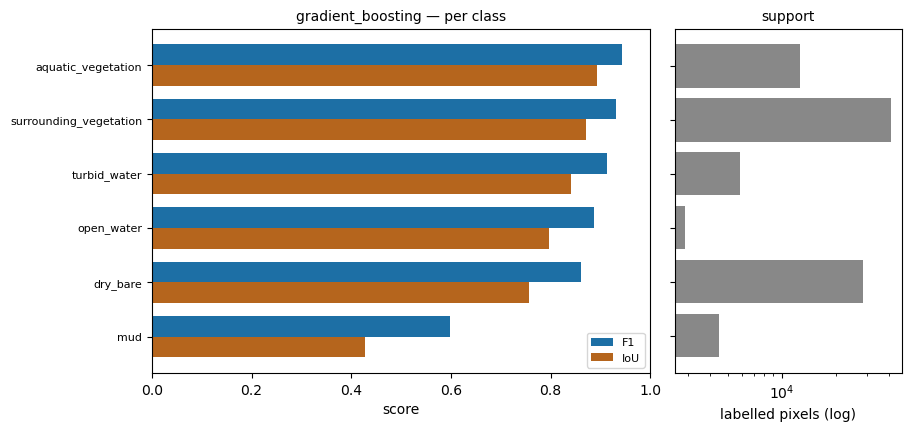

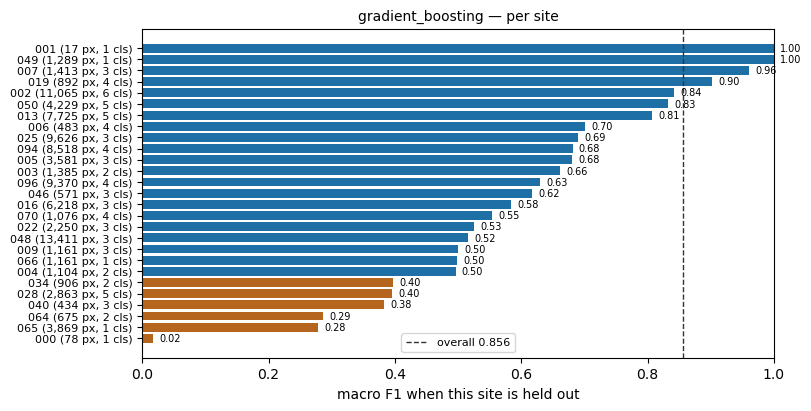

In [37]:
figure = wh_plots.plot_confusion(evaluation, normalise="true")
plt.show()

figure = wh_plots.plot_class_scores(evaluation)
plt.show()

figure = wh_plots.plot_site_scores(evaluation)
plt.show()

## Ablation: which feature blocks earn their place?

Every set below contains exactly the columns its name says — an earlier version quietly
folded the embeddings into `instantaneous_only`, which made a 92-column set look like a
28-column one. Sets that turn out to contain identical columns are scored once and marked
`identical_to` rather than cross-validated repeatedly.

The comparison to read is **`spectral_only` vs `instantaneous_only`**: that is the design's
central claim, that normalising a pixel against its own history makes ambiguous dry-season
months separable. With 16 labelled sites the temporal block has been worth roughly +0.10
macro F1.

**This verdict has moved as labels accumulated**, so re-read the table after each labelling
session rather than treating any one run as settled. At 9 sites the same comparison gave
+0.14 for gradient boosting but only +0.03 for logistic regression — and logistic regression
won overall then, while gradient boosting wins now.

With `harmonic_enabled: false` the harmonic and trend blocks are empty, so `no_harmonic` and
`model_free_temporal` collapse onto `spectral_only`.

In [38]:
ablation = wh_train.run_ablation(
    table, cfg, PARAMS, model_name=BEST,
    train_params=TRAIN,
)
print()
ablation.round(4)

figure = wh_plots.plot_ablation(ablation)
plt.show()

  empty feature block(s): temporal_trend, temporal_harmonic
  all_features             59 features  macro F1 0.854


KeyboardInterrupt: 

## AlphaEarth embeddings

64 learned dimensions per pixel, summarising a year of multi-sensor observation, grid-locked
to the Sentinel-2 chips so no resampling is needed. Static — one annual image applies to
every month.

In [ ]:
if not PARAMS.use_alphaearth:
    print("use_alphaearth is False, so there are no embedding columns to analyse.")
    print("Set it True in the params cell and rebuild the table to run this section.")
else:
    importance = wh_train.permutation_importance_by_site(
        table, cfg, model_name=BEST, n_repeats=3, verbose=True,
        train_params=TRAIN,
    )
    importance.to_csv(cfg.paths["derived"] / "feature_importance.csv")
    print(f"permutation importance over {int(importance['n_folds'].iloc[0])} held-out folds\n")
    print("top 12 features overall:")
    display(importance.head(12).round(4))

  held out fold0:000+001+005+048+064: top ae_A28 0.153, mndwi_sd9 0.038, ae_A63 0.017
  held out fold1:009+019+022+025+065: top mndwi_sd9 0.016, mndwi_mean9 0.016, refl_B4 0.010
  held out fold2:003+006+049+050+070+096: top refl_B5 0.073, mndwi_mean9 0.071, refl_B3 0.060
  held out fold3:002+016+034+040+066: top mndwi_mean9 0.039, mndwi_sd9 0.016, ndvi_mean9 0.013
  held out fold4:004+013+046+094: top mndwi_sd9 0.018, mndwi_mean9 0.015, ae_A63 0.015
permutation importance over 5 held-out folds

top 12 features overall:


,mean_importance,std_across_folds,n_folds_positive,n_folds
ae_A28,0.0295,0.0689,3,5
mndwi_mean9,0.0282,0.0278,4,5
mndwi_sd9,0.0262,0.0130,5,5
ae_A63,0.0151,0.0242,4,5
refl_B3,0.0125,0.0266,3,5
mndwi_sd3,0.0080,0.0037,5,5
ndvi_mean9,0.0068,0.0218,3,5
refl_B6,0.0049,0.0178,2,5
ae_A32,0.0043,0.0068,4,5
red_green_ratio,0.0042,0.0061,4,5


### Which of the 64 bands carry anything?

Permutation importance measured on **held-out** sites, so it ranks features by how much they
help generalise to a new waterhole rather than how well they fit the ones already labelled.

Read the error bars, not the ranking. A band that looks essential in one fold and useless in
the rest is not a finding — bars whose spread crosses zero are drawn in orange, and the
`(n/N)` label counts the folds where the band actually helped.

bands whose spread stays above zero: 0 of 3
total embedding importance 0.0489 vs 0.0948 for everything else (34% of the total)



,mean_importance,std_across_folds,n_folds_positive,n_folds
A28,0.0295,0.0689,3,5
A63,0.0151,0.0242,4,5
A32,0.0043,0.0068,4,5


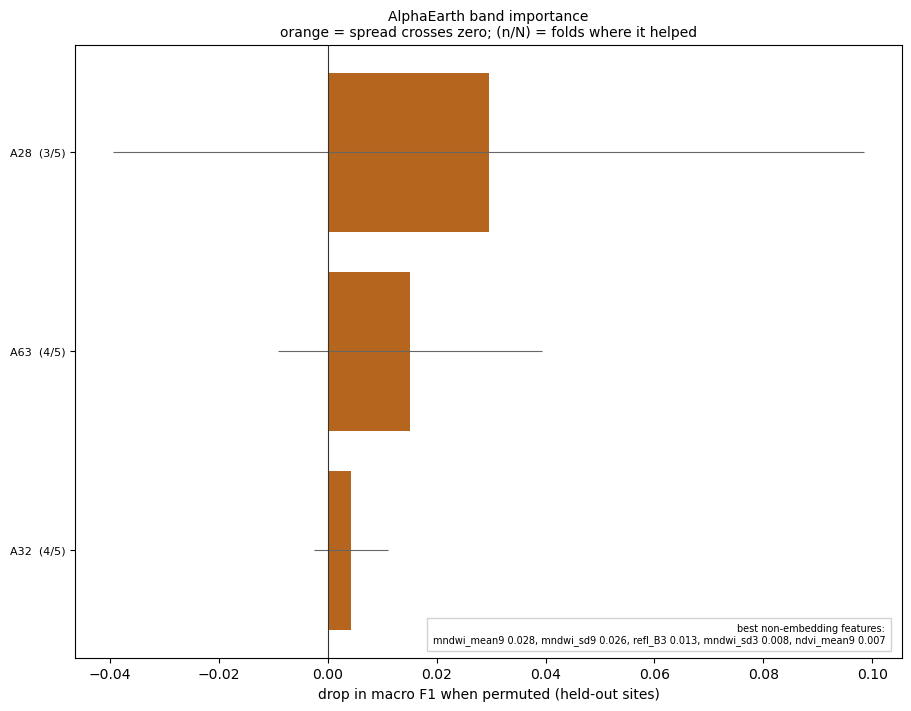

In [ ]:
if PARAMS.use_alphaearth:
    bands = wh_train.band_importance(importance)

    survives = (bands["mean_importance"] - bands["std_across_folds"] > 0).sum()
    embedding_total = bands["mean_importance"].sum()
    other_total = importance[
        ~importance.index.str.startswith(wh_features.ALPHAEARTH_PREFIX)
    ]["mean_importance"].sum()

    print(f"bands whose spread stays above zero: {survives} of {len(bands)}")
    print(f"total embedding importance {embedding_total:.4f} "
          f"vs {other_total:.4f} for everything else "
          f"({100 * embedding_total / (embedding_total + other_total):.0f}% of the total)\n")
    display(bands.head(12).round(4))

    figure = wh_plots.plot_band_importance(bands, n_bands=25, reference=importance)
    plt.show()

### Selecting a subset

`select_top_bands` returns the best-ranked bands, but **choosing them on the same folds that
then report the score is circular** and the resulting number will be optimistic. To quote a
figure for a selected subset, either nest the selection inside each fold or re-score on sites
held out of the selection entirely.

Given the ablation above, a subset is unlikely to be worth the complication here — it is
recorded for when the embeddings are tried on the footprint problem instead.

In [ ]:
if PARAMS.use_alphaearth:
    top_bands = wh_train.select_top_bands(importance, n=10)
    print(f"top 10 bands: {top_bands}")
    print("\nTo try them: set alphaearth_bands=tuple(top_bands) in the params cell,")
    print("rebuild the table, and treat the resulting score as optimistic.")

top 10 bands: ['A28', 'A63', 'A32']

To try them: set alphaearth_bands=tuple(top_bands) in the params cell,
rebuild the table, and treat the resulting score as optimistic.


## Temporal holdout

Reported for completeness and **known to be optimistically biased**: a held-out month's
temporal features were computed from that pixel's whole history, training months included.
Removing that leak would mean recomputing every temporal feature per fold from training
months only.

The grouped-site CV above has no equivalent problem — holding out a site holds out its
history too. Trust that number, not this one.

In [39]:
train_index, test_index = wh_train.temporal_holdout_split(
    table, TRAIN.temporal_holdout_months
)
model = wh_train.make_model(BEST, TRAIN)
model.fit(table.iloc[train_index][features], table.iloc[train_index]["class_id"])
predicted = model.predict(table.iloc[test_index][features])

holdout = wh_train.evaluate_predictions(
    table.iloc[test_index]["class_id"].to_numpy(), predicted,
    table.iloc[test_index]["site_id"].to_numpy(), cfg, BEST, "temporal_holdout",
)
print(holdout.summary(), "  <- optimistically biased, see above")
holdout.per_class.round(3)[["f1", "iou", "support"]]

gradient_boosting      macro F1 0.743  weighted F1 0.937  (25,943 test rows)   <- optimistically biased, see above


,f1,iou,support
class,,,
open_water,0.000,0.000,0
turbid_water,0.900,0.818,732
aquatic_vegetation,0.862,0.758,2202
mud,0.782,0.642,1653
dry_bare,0.944,0.894,9651
surrounding_vegetation,0.969,0.940,11705


## Fit on everything and persist

The final model is fitted on all labelled sites. Its recorded CV score comes from the
grouped cross-validation above, not from this fit — a model scored on its own training data
is meaningless.

The feature list and config hash are saved beside it, because a model applied with features
in a different order produces confident nonsense rather than an error.

In [40]:
final_model = wh_train.make_model(BEST, TRAIN)
final_model.fit(table[features], table["class_id"])

model_path, manifest_path = wh_train.save_model(
    final_model, features, cfg, PARAMS, results[BEST], table,
    train_params=TRAIN
)
print(f"model    -> {model_path}")
print(f"manifest -> {manifest_path}")

model    -> /Users/scottforrest/Library/CloudStorage/OneDrive-SharedLibraries-QueenslandUniversityofTechnology/Aiden Price - Waterhole_WVS/counting_waterholes/cookie-cutting/derived/models/classifier.joblib
manifest -> /Users/scottforrest/Library/CloudStorage/OneDrive-SharedLibraries-QueenslandUniversityofTechnology/Aiden Price - Waterhole_WVS/counting_waterholes/cookie-cutting/derived/models/classifier.json


In [41]:
# Reload and confirm it round-trips.
reloaded, meta = wh_train.load_model(cfg)
print(f"{meta['model_class']}, {meta['n_features']} features, "
      f"CV macro F1 {meta['cv_macro_f1']:.3f}")
assert list(meta["feature_names"]) == list(features)
assert np.array_equal(reloaded.predict(table[features].head(100)),
                      final_model.predict(table[features].head(100)))
print("round-trip OK")

HistGradientBoostingClassifier, 59 features, CV macro F1 0.856
round-trip OK


## Where is the model right and wrong, spatially?

Aggregate metrics say *which* classes are weak. These maps say **where** — and that is what
distinguishes a model problem from a label problem.

**Every prediction here comes from a model that has never seen the site being drawn.**
`fit_without_site` refits on the other 8 sites first. Predicting a site the model was
trained on would look excellent and tell you nothing.

Refitting and loading a site's 84-month stack are both expensive, so both are cached below —
inspecting more months of a site you have already looked at is nearly free.

In [42]:
import wh_footprint

_model_cache = {}
_predictor_cache = {}
_alphaearth_cache = {}

def held_out_view(site_id, year_month):
    """Predict one site-month with a model that never saw that site. Cached."""
    if site_id not in _model_cache:
        print(f"  fitting without site {site_id}...", flush=True)
        _model_cache[site_id] = wh_train.fit_without_site(
            table, cfg, BEST, site_id, features, train_params=TRAIN
        )
    if site_id not in _predictor_cache:
        print(f"  loading site {site_id} history...", flush=True)
        _predictor_cache[site_id] = wh_train.SitePredictor(manifest, cfg, PARAMS, site_id)

    tile, predicted, confidence = _predictor_cache[site_id].predict(
        _model_cache[site_id], features, year_month
    )

    # AlphaEarth panel for context. Loaded even when the model does not use the
    # embeddings as features — it is static per site and cheap, and it shows the
    # basin far more sharply than true colour does.
    if site_id not in _alphaearth_cache:
        try:
            ae_params = wh_features.FeatureParams(use_alphaearth=True)
            bands = wh_features.load_alphaearth(
                cfg, site_id, ae_params, expected_shape=tile.shape
            )
            _alphaearth_cache[site_id] = wh_features.alphaearth_composite(
                bands, bands=("A60", "A24", "A63")
            )
        except (FileNotFoundError, ValueError) as error:
            print(f"  no AlphaEarth for site {site_id}: {error}")
            _alphaearth_cache[site_id] = None

    mask_path = cfg.paths["labels"] / f"{Path(tile.path).stem}_labels.tif"
    manual = wh_tiles.read_mask(mask_path, tile.shape) if mask_path.exists() else None
    try:
        footprint = wh_footprint.load_mask(cfg, site_id)
    except FileNotFoundError:
        footprint = None
    return tile, predicted, confidence, manual, footprint, _alphaearth_cache[site_id]


candidates = wh_train.labelled_tiles(cfg).sort_values(
    ["n_classes", "n_labelled"], ascending=False
)
print(f"{len(candidates)} hand-labelled tiles available")
candidates.head(10)[["site_id", "year_month", "n_classes", "n_labelled"]]

313 hand-labelled tiles available


,site_id,year_month,n_classes,n_labelled
93,013,2025-08,3,2055
20,002,2020-05,3,1902
278,094,2019-12,2,3513
279,094,2020-01,2,2515
215,048,2021-01,2,2362
143,025,2019-05,2,2325
23,002,2020-10,2,2137
92,013,2025-07,2,2041
22,002,2020-09,2,1964
142,025,2019-04,2,1754


  fitting without site 013...
  loading site 013 history...


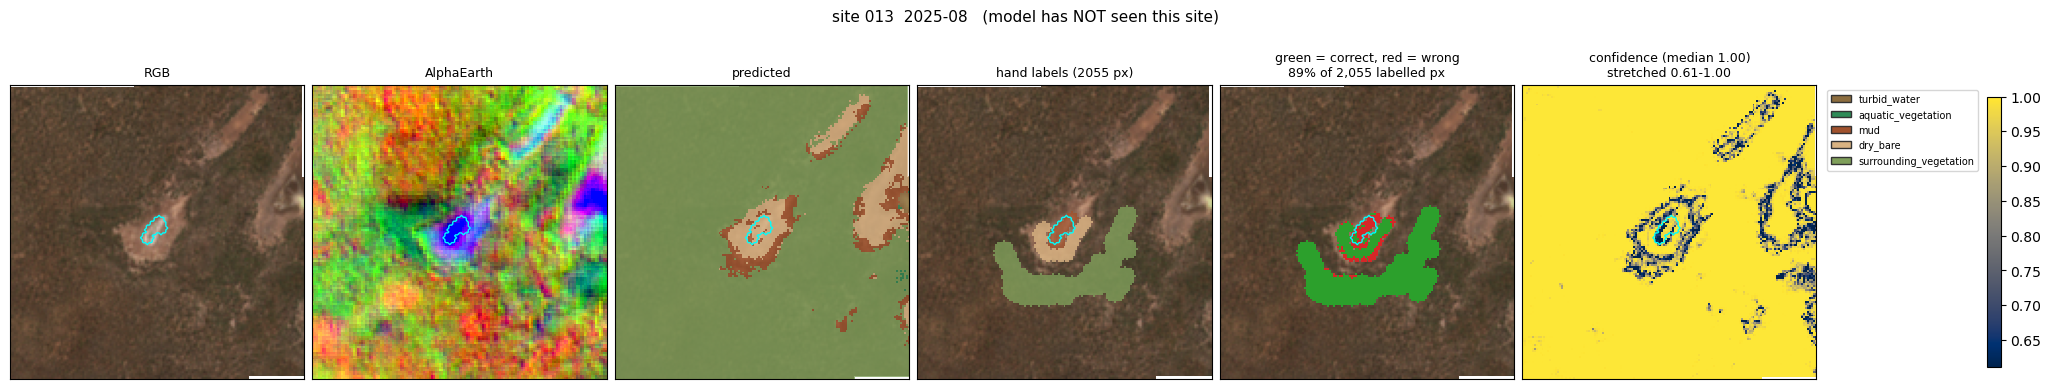

  fitting without site 002...
  loading site 002 history...


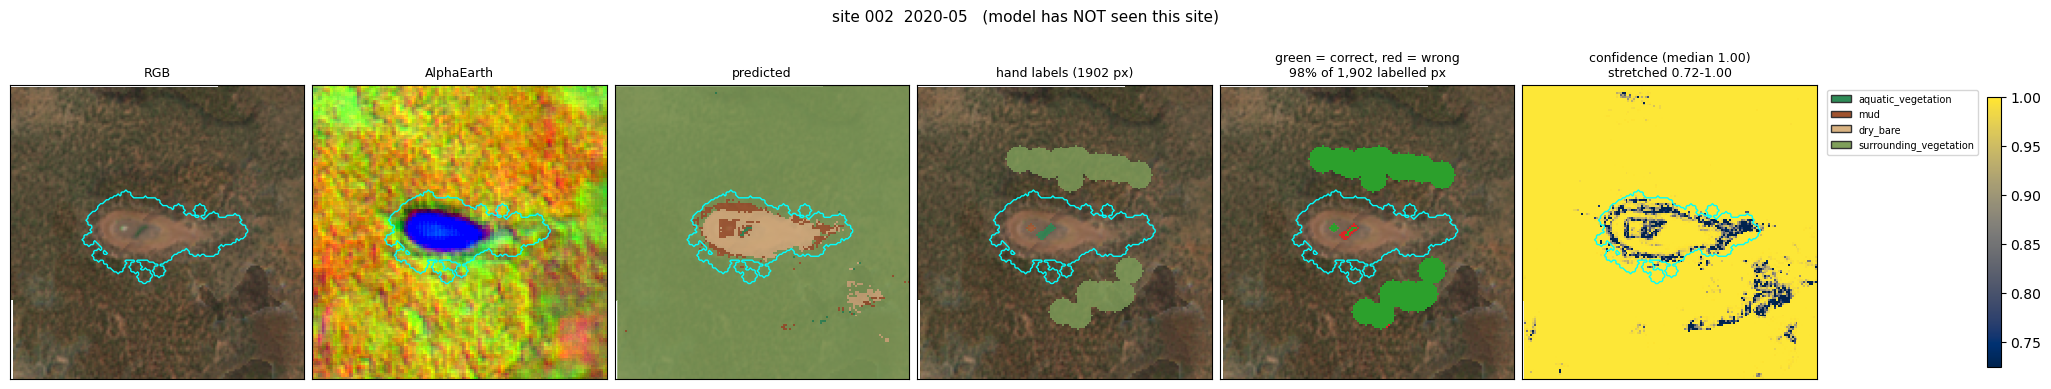

  fitting without site 094...
  loading site 094 history...


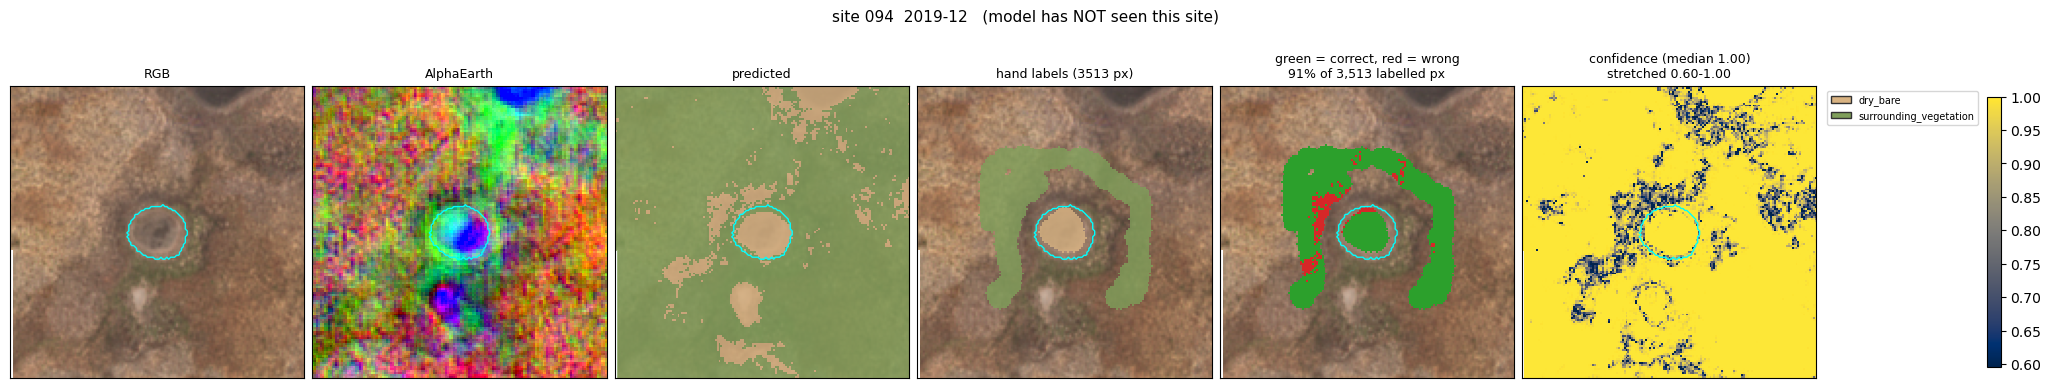

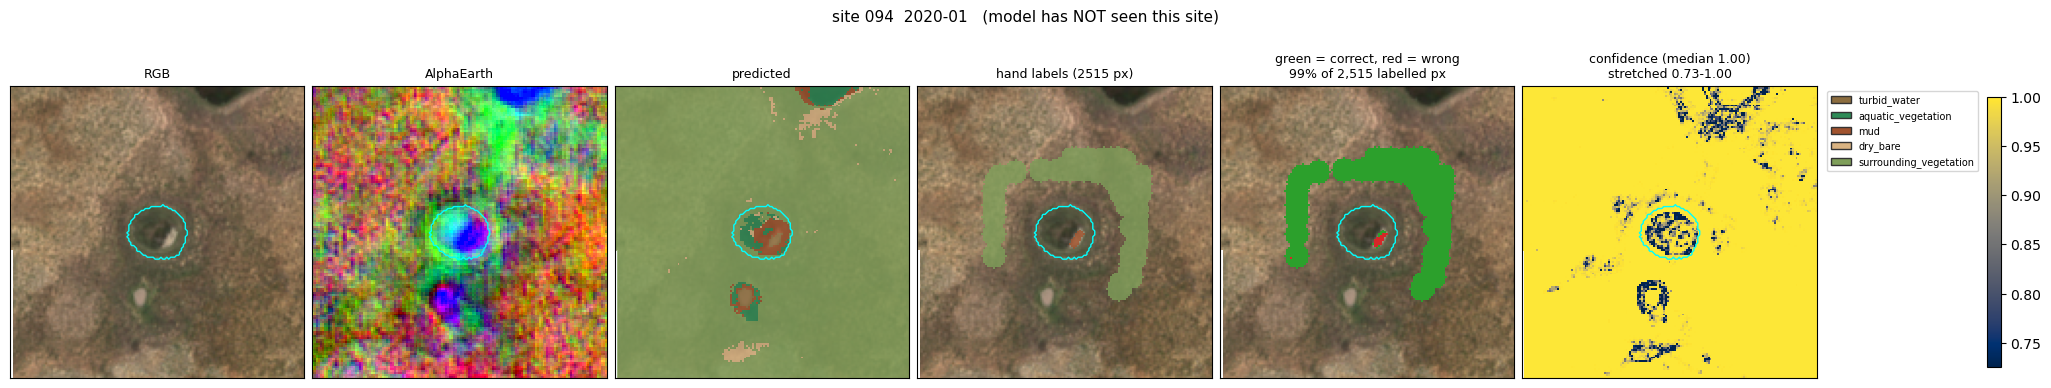

  fitting without site 048...
  loading site 048 history...


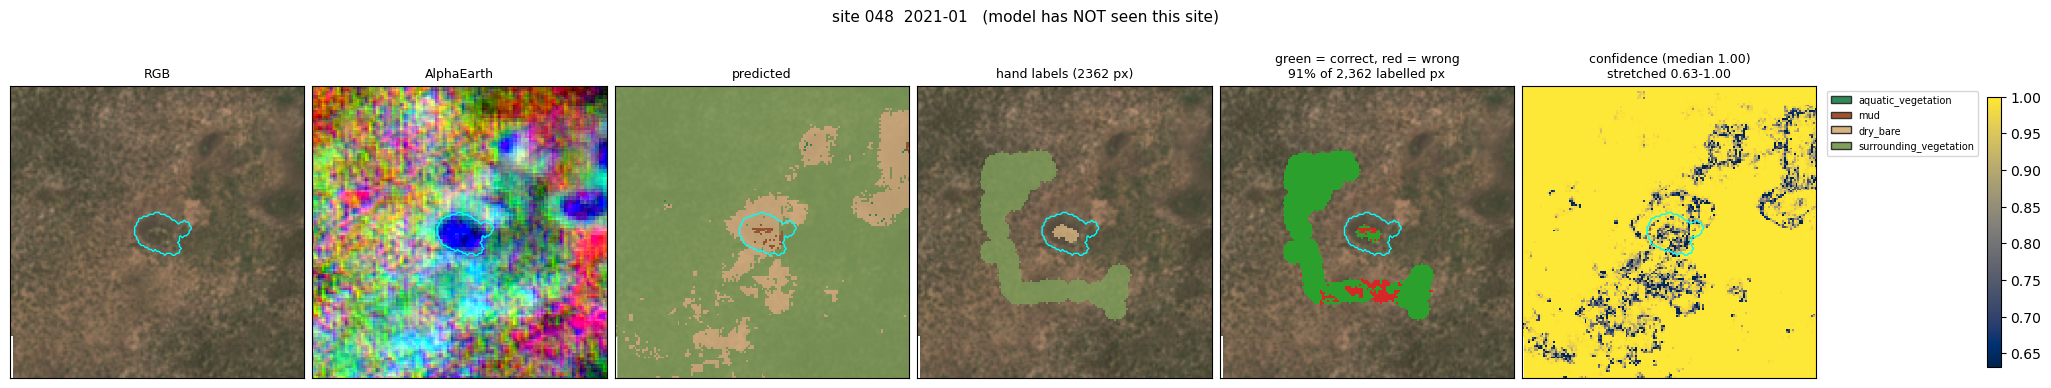

In [43]:
INSPECT = [
    (candidates.iloc[0]["site_id"], candidates.iloc[0]["year_month"]),
    (candidates.iloc[1]["site_id"], candidates.iloc[1]["year_month"]),
    (candidates.iloc[2]["site_id"], candidates.iloc[2]["year_month"]),
    (candidates.iloc[3]["site_id"], candidates.iloc[3]["year_month"]),
    (candidates.iloc[4]["site_id"], candidates.iloc[4]["year_month"]),
    
]

for site_id, year_month in INSPECT:
    tile, predicted, confidence, manual, footprint, alphaearth = held_out_view(
        site_id, year_month
    )
    figure = wh_plots.plot_prediction_map(
        tile, predicted, cfg, manual, confidence, footprint,
        held_out=True, alphaearth=alphaearth,
    )
    plt.show()

**Reading the agreement panel.** Green is correct, red is wrong, and unlabelled pixels are
left showing the imagery. Look for structure: errors concentrated in the basin interior mean
something different from errors scattered along class boundaries.

Boundary errors are largely mixed pixels and are expected. Errors filling a whole region —
especially at *high* confidence — mean the model has learned something wrong about that
surface, and are worth chasing.

### What each class gets mistaken for, in place

Splits the previous view by hand-labelled class: green where that class was got right, and
the colour of whatever it was confused with where it was not. This answers "my mud is being
called dry ground — everywhere, or only at the basin margin?", which the confusion matrix
cannot.

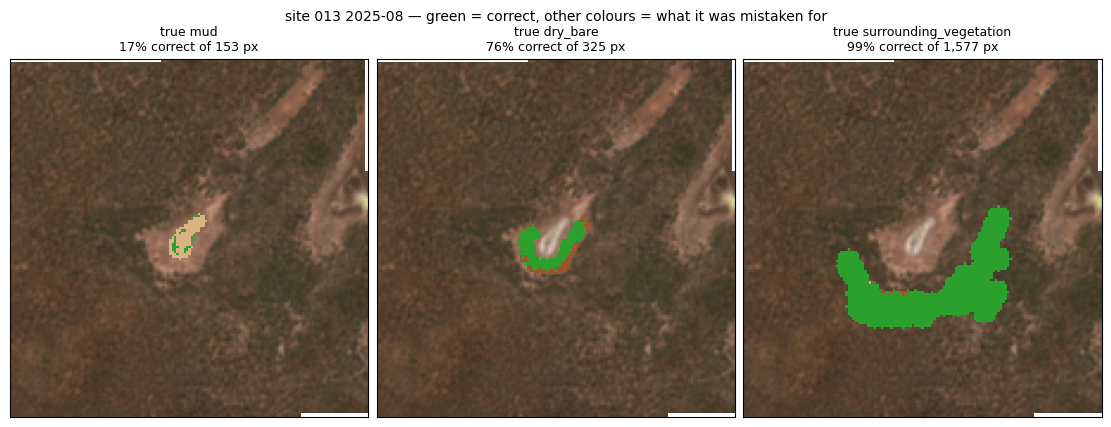

In [44]:
site_id, year_month = INSPECT[0]
tile, predicted, _, manual, _, _ = held_out_view(site_id, year_month)

figure = wh_plots.plot_error_by_class_map(tile, predicted, manual, cfg)
plt.show()

### The same waterhole through time

One site across several months, from a model that has never seen it. Drying should show as
an orderly progression; if the predicted composition jumps around between adjacent months,
that is either a compositing artefact or the model being unstable — and the temporal
consistency pass in deliverable 7 is what will deal with it.

The site stack loads once here, so extra months are cheap.

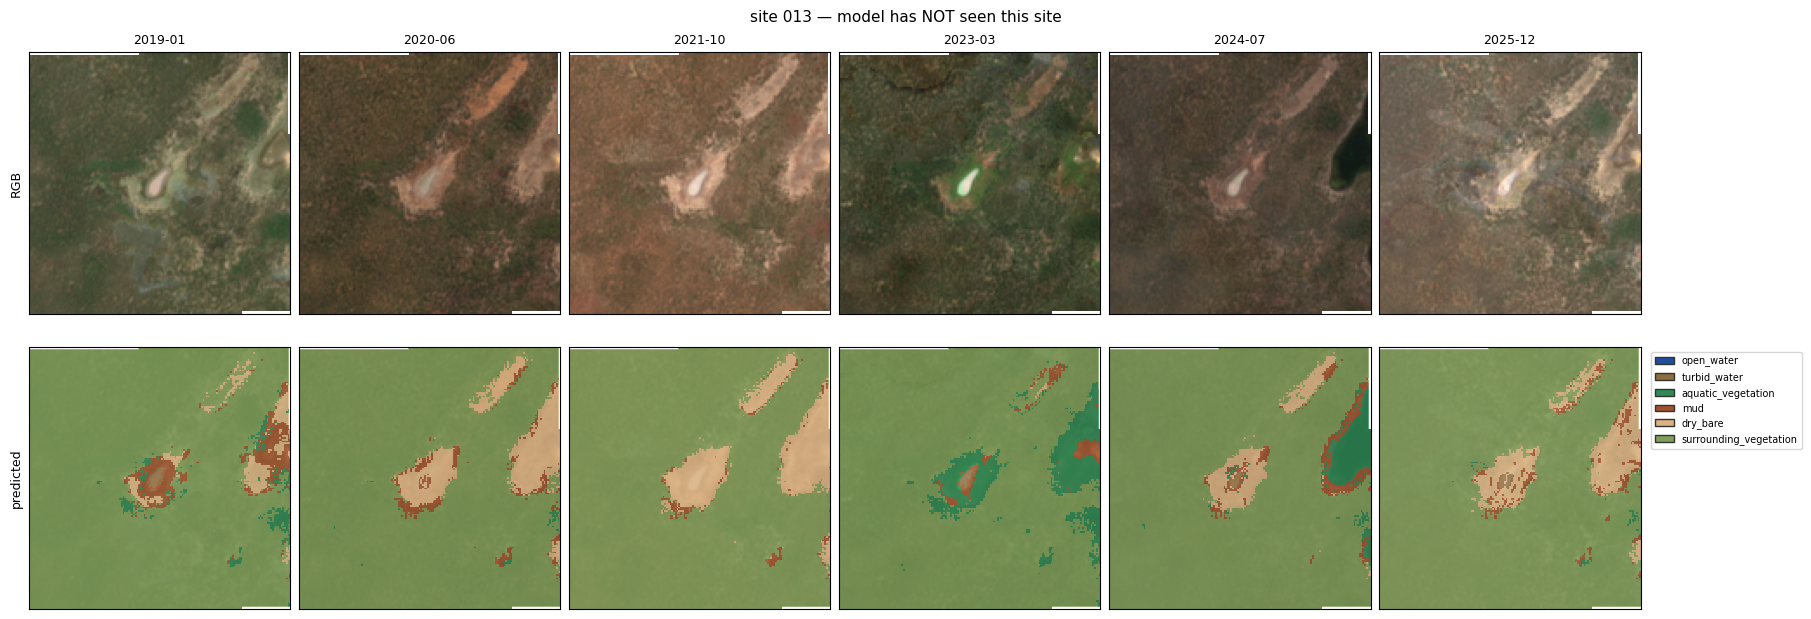

In [45]:
TIMESERIES_SITE = INSPECT[0][0]
N_MONTHS = 6

predictor = _predictor_cache[TIMESERIES_SITE]
months = predictor.months
chosen = [months[i] for i in np.linspace(0, len(months) - 1, N_MONTHS).round().astype(int)]

figure, axes = plt.subplots(2, len(chosen), figsize=(3.0 * len(chosen), 6.2),
                            constrained_layout=True)
for column, year_month in enumerate(chosen):
    tile, predicted, _, _, _, _ = held_out_view(TIMESERIES_SITE, year_month)
    axes[0, column].imshow(wh_plots.rgb_composite(tile))
    axes[0, column].set_title(year_month, fontsize=9)
    axes[1, column].imshow(wh_plots.rgb_composite(tile))
    axes[1, column].imshow(wh_plots.class_overlay(predicted, cfg, alpha=0.8),
                           interpolation="nearest")
    for row in (0, 1):
        axes[row, column].set_xticks([])
        axes[row, column].set_yticks([])

axes[0, 0].set_ylabel("RGB", fontsize=9)
axes[1, 0].set_ylabel("predicted", fontsize=9)
wh_plots.class_legend(axes[1, -1], cfg)
figure.suptitle(f"site {TIMESERIES_SITE} — model has NOT seen this site", fontsize=11)
plt.show()

## Where to spend the next labelling session

Your last session took the model from 0.55 to 0.80 macro F1 and inverted the model ranking —
that is what being label-limited looks like when the limit lifts. The same reasoning applies
to what to do next: classes at fewer than 3 sites cannot be cross-validated at all, and sites
with low per-site F1 are where generalisation is failing.

`mud` is the class to look at hardest. It has plenty of sites now, so poor performance there
is no longer a coverage problem — it is either a real limit of monthly medians at 10 m, or a
labelling-consistency problem like the mud/dry_bare inversion found at site 013.

In [46]:
print("classes needing more SITES (not more pixels):")
print(coverage[coverage["sites"] < 4][["class", "pixels", "sites"]].to_string(index=False))

print("\nworst-performing sites — look at these in the labeller and check the labels "
      "are right before blaming the model:")
print(evaluation.per_site.head(3).round(3).to_string())

classes needing more SITES (not more pixels):
Empty DataFrame
Columns: [class, pixels, sites]
Index: []

worst-performing sites — look at these in the labeller and check the labels are right before blaming the model:
         n_pixels  n_classes  macro_f1  accuracy
site_id                                         
000            78          1     0.017     0.026
065          3869          1     0.278     0.384
064           675          2     0.287     0.776
